# Análisis de texto NLP: reviews

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Cargar las reseñas
reviews = pd.read_csv("reviews_restaurants_2021_2022.csv")

In [3]:
print(reviews.shape)
reviews.head()
reviews.info()

(429746, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429746 entries, 0 to 429745
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   review_id    429746 non-null  object 
 1   user_id      429746 non-null  object 
 2   business_id  429746 non-null  object 
 3   stars        429746 non-null  float64
 4   useful       429746 non-null  int64  
 5   funny        429746 non-null  int64  
 6   cool         429746 non-null  int64  
 7   text         429746 non-null  object 
 8   date         429746 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 29.5+ MB


Se traen los ids de train y de test del notebook anterior.

In [4]:
train_ids = pd.read_csv("train_business_ids.csv")
test_ids = pd.read_csv("test_business_ids.csv")

y se filtran las reseñas por train y test.

In [5]:
reviews_train = reviews[reviews["business_id"].isin(train_ids["business_id"])].copy()
reviews_test = reviews[reviews["business_id"].isin(test_ids["business_id"])].copy()

print("Reviews train:", reviews_train.shape)
print("Reviews test :", reviews_test.shape)

Reviews train: (344753, 9)
Reviews test : (84993, 9)


## Limpieza del texto

In [6]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

#nltk.download("stopwords")
#nltk.download("wordnet")

In [7]:
#Limpiar el texto 
# Stopwords en inglés
stop_words = set(stopwords.words("english"))

# Lematizador
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # 1. Comprobar nulos
    if pd.isna(text):
        return ""
    
    # 2. Pasar todo a minúsculas
    text = text.lower()
    
    # 3. Eliminar números y signos de puntuación
    text = re.sub(r"[^a-z\s]", "", text)
    
    # 4. Separar el texto en palabras
    words = text.split()
    
    # 5. Eliminar stopwords
    words = [word for word in words if word not in stop_words]
    
    # 6. Lematizar palabras
    words = [lemmatizer.lemmatize(word) for word in words]
    
    # 7. Volver a unir las palabras en un texto limpio
    return " ".join(words)

# Aplicarlo a la columna de texto
reviews_train["clean_text"] = reviews_train["text"].apply(clean_text)
reviews_test["clean_text"] = reviews_test["text"].apply(clean_text)

## Visualización

In [8]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text_all = " ".join(reviews_train["clean_text"])

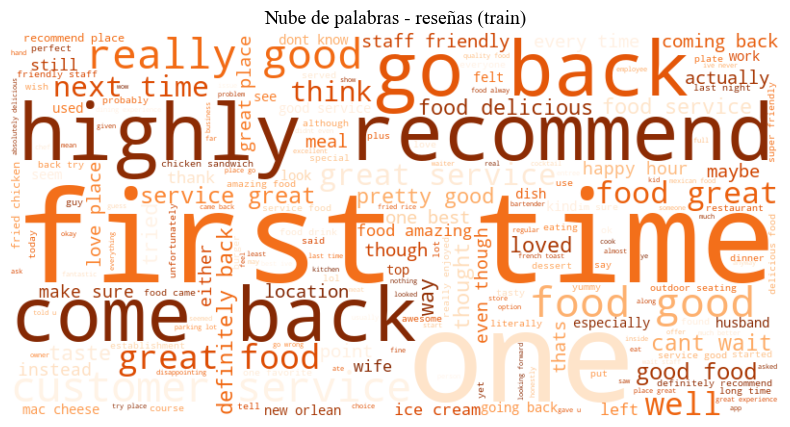

In [9]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Estética
plt.rcParams["font.family"] = "Times New Roman"

# Unir todo el texto limpio
text_all = " ".join(reviews_train["clean_text"])

# Generar wordcloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="Oranges"
).generate(text_all)

# Plot
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras - reseñas (train)", fontsize=14)

plt.show()

In [10]:
extra_stopwords = {
    "one","time","next","back","got","go","going","come","came",
    "also","really","still","even","well","make","made","get","getting",
    "us","im","ive","dont","didnt","cant","could","would",
    "thing","things","way","know","think",
    "restaurant","food","customer","definitely","recommend"
}

In [11]:
#Añadir las extra
stop_words = set(stopwords.words("english"))
stop_words.update(extra_stopwords)

#Volver a limpiar el texto
stop_words = set(stopwords.words("english"))
stop_words.update(extra_stopwords)

reviews_train["clean_text"] = reviews_train["text"].apply(clean_text)
reviews_test["clean_text"] = reviews_test["text"].apply(clean_text)

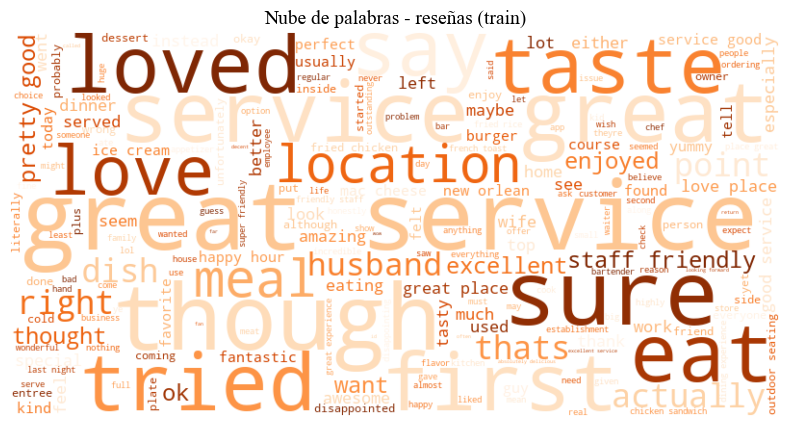

In [12]:
#Repetir la nube de palabras
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Estética
plt.rcParams["font.family"] = "Times New Roman"

# Unir todo el texto limpio
text_all = " ".join(reviews_train["clean_text"])

# Generar wordcloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="Oranges"
).generate(text_all)

# Plot
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras - reseñas (train)", fontsize=14)

plt.show()

## Análisis de sentimiento

- -1  → sentimiento negativo
- 0   → neutro
- 1   → positivo

In [13]:
#Representación tf-idf
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=2000)

X_tfidf_train = tfidf.fit_transform(reviews_train["clean_text"])
X_tfidf_test = tfidf.transform(reviews_test["clean_text"])

In [14]:
#Ver algunas palabras
tfidf.get_feature_names_out()[:20]

array(['able', 'absolute', 'absolutely', 'accommodate', 'accommodating',
       'acknowledged', 'across', 'act', 'actual', 'actually', 'add',
       'added', 'adding', 'addition', 'additional', 'adult', 'advance',
       'affordable', 'afternoon', 'age'], dtype=object)

In [15]:
#!pip install textblob
from textblob import TextBlob

reviews_train["sentiment"] = reviews_train["text"].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

reviews_test["sentiment"] = reviews_test["text"].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

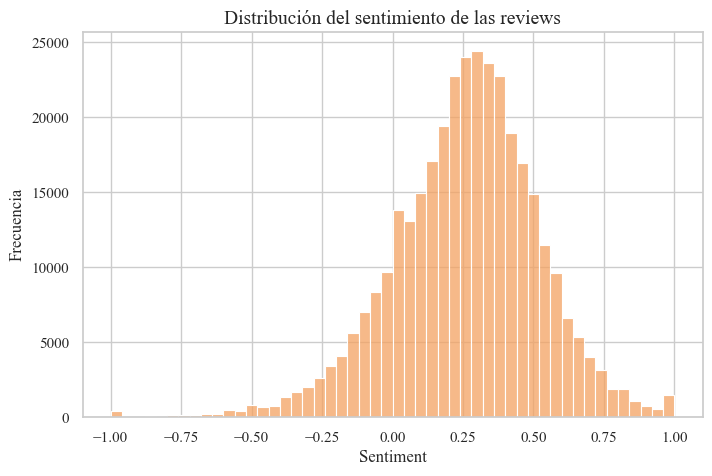

In [16]:
#Distribución del sentimiento
import seaborn as sns
import matplotlib.pyplot as plt

# Estilo
sns.set_style("whitegrid")
sns.set_context("notebook")
plt.rcParams["font.family"] = "Times New Roman"

# Gráfico
plt.figure(figsize=(8,5))

sns.histplot(
    reviews_train["sentiment"],
    bins=50,
    color="#F4A261",
    edgecolor="white"
)

plt.title("Distribución del sentimiento de las reviews", fontsize=14)
plt.xlabel("Sentiment", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)

plt.show()

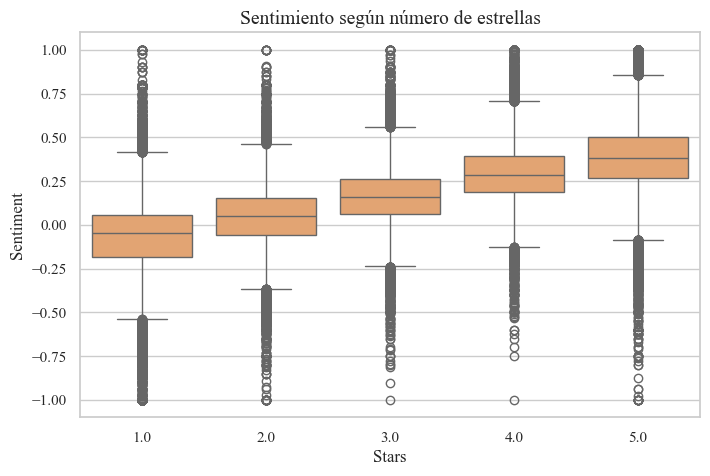

In [17]:
#Sentimiento según número de estrellas
import seaborn as sns
import matplotlib.pyplot as plt

# Estilo
sns.set_style("whitegrid")
sns.set_context("notebook")
plt.rcParams["font.family"] = "Times New Roman"

# Gráfico
plt.figure(figsize=(8,5))

sns.boxplot(
    x="stars",
    y="sentiment",
    data=reviews_train,
    color="#F4A261"
)

plt.title("Sentimiento según número de estrellas", fontsize=14)
plt.xlabel("Stars", fontsize=12)
plt.ylabel("Sentiment", fontsize=12)

plt.show()

In [18]:
#Sentimiento medio por stars
reviews_train.groupby("stars")["sentiment"].mean()

stars
1.0   -0.073084
2.0    0.044937
3.0    0.162277
4.0    0.295445
5.0    0.392887
Name: sentiment, dtype: float64

In [19]:
#Categorías de sentimiento
def sentiment_category(x):
    if x > 0.1:
        return "positive"
    elif x < -0.1:
        return "negative"
    else:
        return "neutral"

reviews_train["sentiment_category"] = reviews_train["sentiment"].apply(sentiment_category)

In [20]:
#Proporción de tipos de reviews
reviews_train["sentiment_category"].value_counts(normalize=True)

sentiment_category
positive    0.754349
neutral     0.163366
negative    0.082285
Name: proportion, dtype: float64

## Crear las variables para cada restaurante

In [21]:
sentiment_train = reviews_train.groupby("business_id").agg(
    mean_sentiment=("sentiment", "mean"),
    std_sentiment=("sentiment", "std"),
    positive_ratio=("sentiment", lambda x: (x > 0.1).mean()),
    negative_ratio=("sentiment", lambda x: (x < -0.1).mean())
).reset_index()

sentiment_test = reviews_test.groupby("business_id").agg(
    mean_sentiment=("sentiment", "mean"),
    std_sentiment=("sentiment", "std"),
    positive_ratio=("sentiment", lambda x: (x > 0.1).mean()),
    negative_ratio=("sentiment", lambda x: (x < -0.1).mean())
).reset_index()

### Info de las variables creadas

In [22]:
# Variables de sentimiento agregadas
sent_cols = ["mean_sentiment", "std_sentiment", "positive_ratio", "negative_ratio"]

# Resumen estadístico
print(sentiment_train[sent_cols].describe().T)

                  count      mean       std  min       25%       50%  \
mean_sentiment  25458.0  0.197322  0.190255 -1.0  0.090410  0.233686   
std_sentiment   21761.0  0.228510  0.099835  0.0  0.170843  0.221564   
positive_ratio  25458.0  0.656515  0.321448  0.0  0.500000  0.750000   
negative_ratio  25458.0  0.134998  0.227212  0.0  0.000000  0.008197   

                     75%       max  
mean_sentiment  0.322784  1.000000  
std_sentiment   0.275630  1.016466  
positive_ratio  0.924528  1.000000  
negative_ratio  0.176471  1.000000  


In [23]:
print(sentiment_train[sent_cols].isnull().sum())

mean_sentiment       0
std_sentiment     3697
positive_ratio       0
negative_ratio       0
dtype: int64


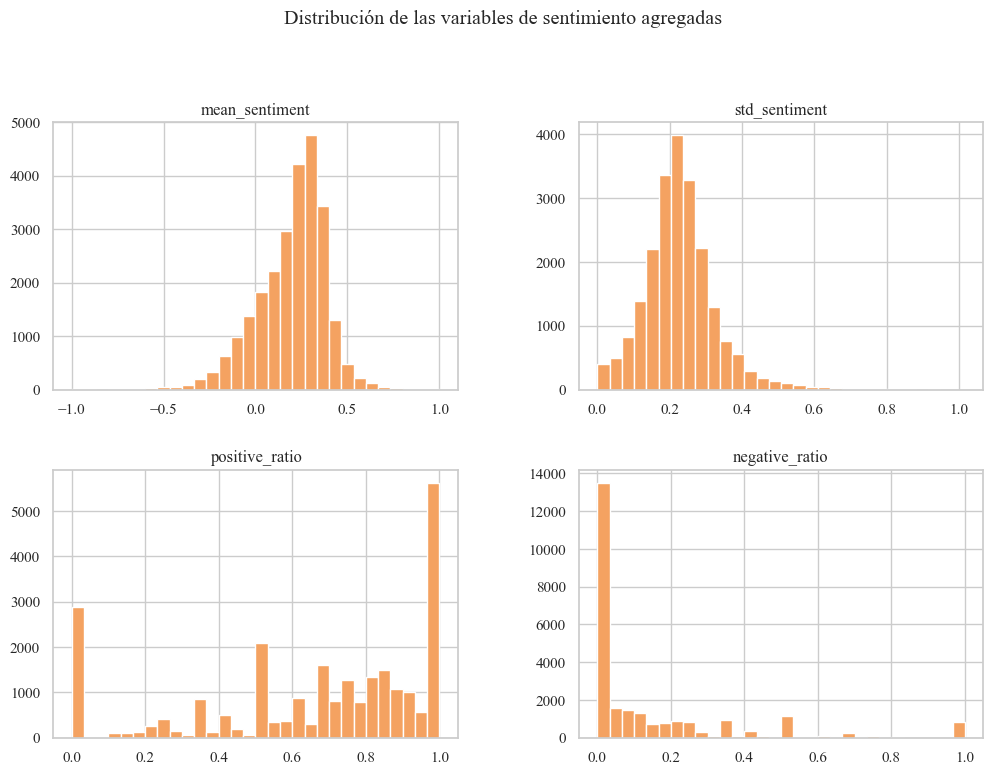

In [24]:
import matplotlib.pyplot as plt

sentiment_train[sent_cols].hist(figsize=(12, 8), bins=30, color="#F4A261")

plt.suptitle("Distribución de las variables de sentimiento agregadas", y=1.02)

plt.show()

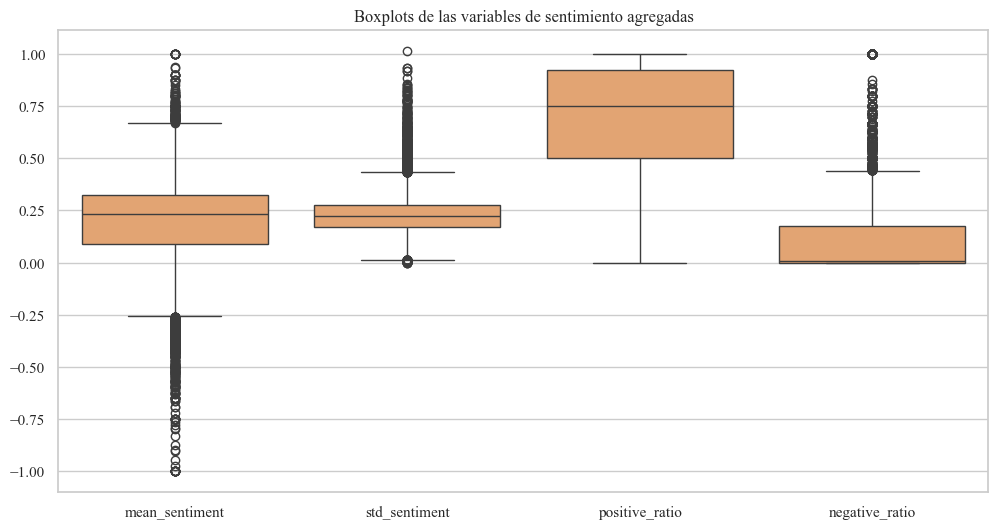

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.boxplot(data=sentiment_train[sent_cols], color="#F4A261")

plt.title("Boxplots de las variables de sentimiento agregadas")
plt.show()

In [26]:
print("Negocios con mayor sentimiento medio:")
print(sentiment_train.sort_values("mean_sentiment", ascending=False).head(10))

print("\nNegocios con menor sentimiento medio:")
print(sentiment_train.sort_values("mean_sentiment", ascending=True).head(10))

print("\nNegocios con mayor variabilidad de sentimiento:")
print(sentiment_train.sort_values("std_sentiment", ascending=False).head(10))

Negocios con mayor sentimiento medio:
                  business_id  mean_sentiment  std_sentiment  positive_ratio  \
25457  zznZqH9CiAznbkV6fXyHWA          1.0000            NaN             1.0   
4233   9Ts67ze80oVWNPb9Muimsw          1.0000            NaN             1.0   
18114  hOupS2QRNIuMLfcpOqC0oA          1.0000            NaN             1.0   
47     -6kNhGurAbdNQanqbAaoMg          1.0000            NaN             1.0   
7021   GI9t5STLrfPcowdXjeomag          1.0000            NaN             1.0   
23025  ti88Y6uwIkIt2-m6i5XaSw          1.0000            NaN             1.0   
3074   6X1uRuf4Ykdt0prs_xqz6w          1.0000            NaN             1.0   
6176   EB5pnHGHthrpHw4875lzBg          1.0000            NaN             1.0   
24227  wp_fwjX8JJC85F-sgb7ASg          1.0000            NaN             1.0   
22867  tJxrkonV5iuVZUNJev0jWA          0.9375            NaN             1.0   

       negative_ratio  
25457             0.0  
4233              0.0  
18114    

count    25458.000000
mean        13.542030
std         23.237284
min          1.000000
25%          2.000000
50%          6.000000
75%         15.000000
max        628.000000
Name: n_reviews, dtype: float64


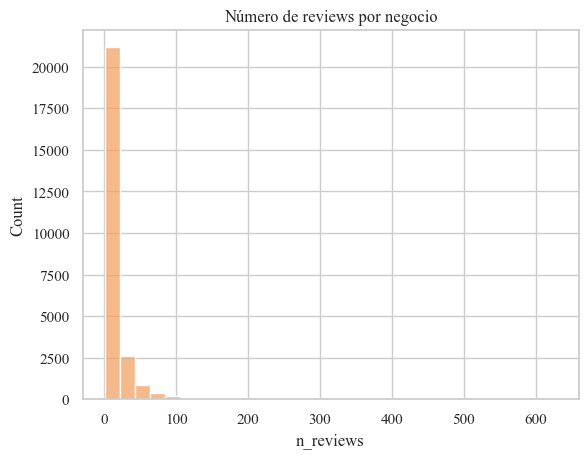

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Número de reviews por negocio
n_reviews_train = reviews_train.groupby("business_id").size().reset_index(name="n_reviews")

# Merge correcto (sin color)
sentiment_train_eda = sentiment_train.merge(
    n_reviews_train,
    on="business_id",
    how="left"
)

# Resumen
print(sentiment_train_eda["n_reviews"].describe())

# Histograma en naranja
sns.histplot(sentiment_train_eda["n_reviews"], bins=30, color="#F4A261")

plt.title("Número de reviews por negocio")
plt.show()

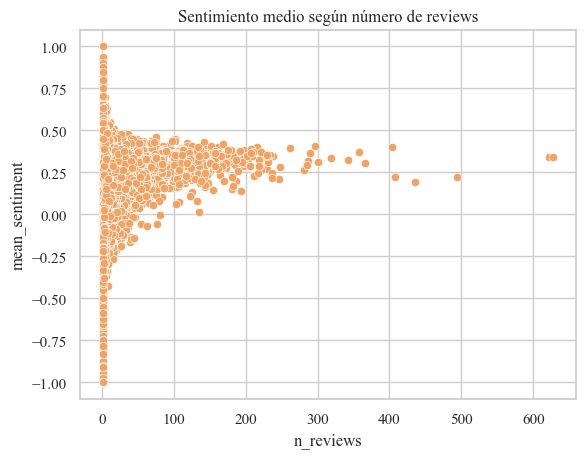

In [28]:
sns.scatterplot(
    data=sentiment_train_eda,
    x="n_reviews",
    y="mean_sentiment",
    color="#F4A261"
)

plt.title("Sentimiento medio según número de reviews")
plt.show()

## Modelado por temas

In [29]:
reviews_train_topics = reviews_train[["business_id", "clean_text"]].copy()
reviews_test_topics = reviews_test[["business_id", "clean_text"]].copy()

reviews_train_topics["clean_text"] = reviews_train_topics["clean_text"].fillna("")
reviews_test_topics["clean_text"] = reviews_test_topics["clean_text"].fillna("")

In [30]:
#Vectorizar el texto
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.90
)

X_train_text = vectorizer.fit_transform(reviews_train_topics["clean_text"])
X_test_text = vectorizer.transform(reviews_test_topics["clean_text"])

In [31]:
#Ajustar el modelo LDA
from sklearn.decomposition import LatentDirichletAllocation

n_topics = 5

lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42
)

train_topic_dist = lda.fit_transform(X_train_text)
test_topic_dist = lda.transform(X_test_text)

### Palabras clave de cada tema

In [32]:
feature_names = vectorizer.get_feature_names_out()

def print_top_words(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_features = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Tema {topic_idx}: {', '.join(top_features)}")

print_top_words(lda, feature_names, n_top_words=10)

Tema 0: pizza, good, cheese, ordered, chicken, salad, sauce, fry, burger, like
Tema 1: order, minute, table, service, said, place, like, never, asked, told
Tema 2: place, best, delicious, sandwich, breakfast, love, amazing, good, coffee, fresh
Tema 3: great, service, place, good, friendly, staff, amazing, drink, delicious, nice
Tema 4: good, chicken, place, like, taco, rice, ordered, flavor, dish, price


In [33]:
topic_labels = {
    0: "Comida (platos específicos)",
    1: "Servicio y atención",
    2: "Calidad de la comida",
    3: "Experiencia general",
    4: "Comida y precio"
}

In [34]:
#Obtener el tema dominante de cada review
import numpy as np

reviews_train_topics["dominant_topic"] = np.argmax(train_topic_dist, axis=1)
reviews_test_topics["dominant_topic"] = np.argmax(test_topic_dist, axis=1)

reviews_train_topics["topic_name"] = reviews_train_topics["dominant_topic"].map(topic_labels)
reviews_test_topics["topic_name"] = reviews_test_topics["dominant_topic"].map(topic_labels)

### Distribución por temas

topic_name
Experiencia general            0.289326
Servicio y atención            0.230722
Comida y precio                0.165664
Calidad de la comida           0.165664
Comida (platos específicos)    0.148625
Name: proportion, dtype: float64


<Axes: title={'center': 'Distribución de temas'}, xlabel='topic_name'>

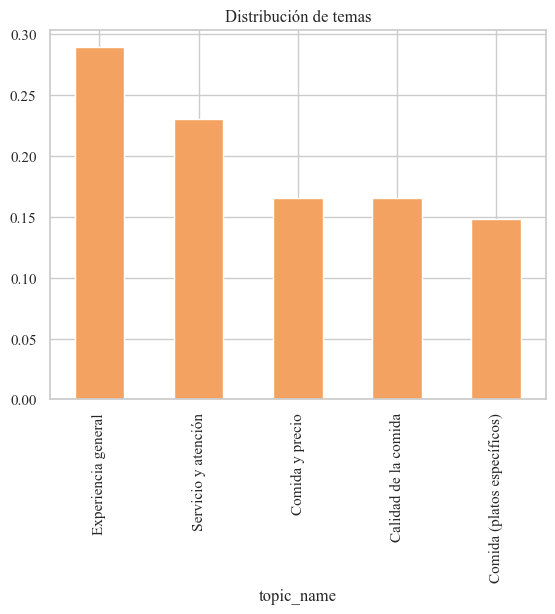

In [35]:
topic_distribution = reviews_train_topics["topic_name"].value_counts(normalize=True)

print(topic_distribution)

topic_distribution.plot(kind="bar", title="Distribución de temas", color="#F4A261")

In [36]:
#Probabilidad de cada tema
for i in range(n_topics):
    reviews_train_topics[f"topic_{i}"] = train_topic_dist[:, i]
    reviews_test_topics[f"topic_{i}"] = test_topic_dist[:, i]

### Crear nuevas variables

In [37]:
#Agregar por business_id
topic_cols = [f"topic_{i}" for i in range(n_topics)]

topics_train_final = reviews_train_topics.groupby("business_id")[topic_cols].mean().reset_index()
topics_test_final = reviews_test_topics.groupby("business_id")[topic_cols].mean().reset_index()

In [38]:
#Obtener el tema dominante por negocio
dominant_topic_train = (
    reviews_train_topics.groupby("business_id")["dominant_topic"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    .reset_index()
    .rename(columns={"dominant_topic": "dominant_topic_business"})
)

dominant_topic_test = (
    reviews_test_topics.groupby("business_id")["dominant_topic"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    .reset_index()
    .rename(columns={"dominant_topic": "dominant_topic_business"})
)

In [39]:
#Añadir el nombre del tema
topics_train_final = topics_train_final.merge(dominant_topic_train, on="business_id", how="left")
topics_test_final = topics_test_final.merge(dominant_topic_test, on="business_id", how="left")

topics_train_final["topic_name"] = topics_train_final["dominant_topic_business"].map(topic_labels)
topics_test_final["topic_name"] = topics_test_final["dominant_topic_business"].map(topic_labels)

## Unir las nuevas variables

In [40]:
#Unir las variables de ANÁLISIS DE SENTIMIENTO + MODELADO POR TEMAS
# Crear esto antes
topics_main_train = topics_train_final[["business_id", "topic_name"]]
topics_main_test = topics_test_final[["business_id", "topic_name"]]

# Sustituir aquí
text_features_train = sentiment_train.merge(
    topics_main_train,
    on="business_id",
    how="left"
)

text_features_test = sentiment_test.merge(
    topics_main_test,
    on="business_id",
    how="left"
)

In [41]:
import pandas as pd

X_train_cluster = pd.read_csv("X_train_cluster.csv")
X_test_cluster = pd.read_csv("X_test_cluster.csv")

#Agregar las nuevas variables al dataset
# TRAIN
X_train_mod = X_train_cluster.merge(
    text_features_train,
    on="business_id",
    how="left"
)

# TEST
X_test_mod = X_test_cluster.merge(
    text_features_test,
    on="business_id",
    how="left"
)

In [42]:
#REVISAR
print(X_train_mod.shape, X_test_mod.shape)

# Ver cuántos nulos han aparecido
print(X_train_mod.isnull().sum().sort_values(ascending=False).head(10))

(25458, 73) (6365, 73)
std_sentiment                     3697
log_num__review_count                0
cat__state_TN                        0
cat__city_grouped_nashville          0
cat__city_grouped_metairie           0
cat__city_grouped_indianapolis       0
cat__city_grouped_edmonton           0
cat__city_grouped_clearwater         0
cat__city_grouped_boise              0
cat__state_PA                        0
dtype: int64


In [43]:
print(X_train_mod.columns)

Index(['log_num__review_count', 'log_num__n_reviews', 'log_num__sum_useful',
       'log_num__n_checkins', 'num__latitude', 'num__longitude',
       'num__cat_Nightlife', 'num__cat_Sandwiches', 'num__cat_Bars',
       'num__cat_American_Traditional', 'num__cat_Fast_Food', 'num__cat_Pizza',
       'num__cat_Breakfast_&_Brunch', 'num__cat_Burgers',
       'num__cat_American_New', 'num__cat_Mexican', 'num__cat_Italian',
       'num__cat_Coffee_&_Tea', 'num__cat_Seafood', 'num__cat_Salad',
       'num__BusinessAcceptsCreditCards', 'num__BikeParking',
       'num__RestaurantsPriceRange2', 'num__open_days_count',
       'num__open_weekend', 'num__open_7_days', 'num__first_year',
       'num__last_year', 'num__review_days',
       'num__trayectoria_trayectoria_baja',
       'num__trayectoria_trayectoria_media_baja',
       'num__trayectoria_trayectoria_media_alta',
       'num__trayectoria_trayectoria_alta', 'cat__state_AB', 'cat__state_AZ',
       'cat__state_CA', 'cat__state_DE', 'cat__stat

### Relación entre variables

In [44]:
import pandas as pd

y_reg = pd.read_csv("y_reg.csv")
y_clf = pd.read_csv("y_clf.csv")

#Unirlo SOLO para comparar
X_train_nlpr = X_train_mod.merge(
    y_reg,
    on="business_id",
    how="left"
)

X_train_nlpc = X_train_mod.merge(
    y_clf,
    on="business_id",
    how="left"
)

In [45]:
print(X_train_nlpr.columns)

Index(['log_num__review_count', 'log_num__n_reviews', 'log_num__sum_useful',
       'log_num__n_checkins', 'num__latitude', 'num__longitude',
       'num__cat_Nightlife', 'num__cat_Sandwiches', 'num__cat_Bars',
       'num__cat_American_Traditional', 'num__cat_Fast_Food', 'num__cat_Pizza',
       'num__cat_Breakfast_&_Brunch', 'num__cat_Burgers',
       'num__cat_American_New', 'num__cat_Mexican', 'num__cat_Italian',
       'num__cat_Coffee_&_Tea', 'num__cat_Seafood', 'num__cat_Salad',
       'num__BusinessAcceptsCreditCards', 'num__BikeParking',
       'num__RestaurantsPriceRange2', 'num__open_days_count',
       'num__open_weekend', 'num__open_7_days', 'num__first_year',
       'num__last_year', 'num__review_days',
       'num__trayectoria_trayectoria_baja',
       'num__trayectoria_trayectoria_media_baja',
       'num__trayectoria_trayectoria_media_alta',
       'num__trayectoria_trayectoria_alta', 'cat__state_AB', 'cat__state_AZ',
       'cat__state_CA', 'cat__state_DE', 'cat__stat

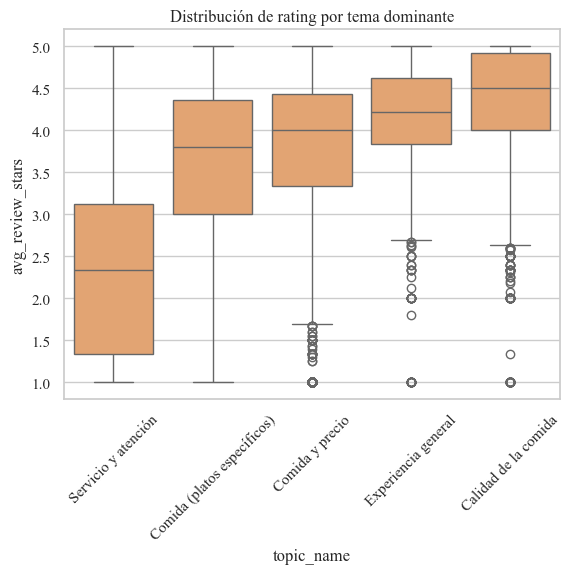

In [46]:
sns.boxplot(
    data=X_train_nlpr,
    x="topic_name",
    y="avg_review_stars",
    color="#F4A261"
)

plt.title("Distribución de rating por tema dominante")
plt.xticks(rotation=45)
plt.show()

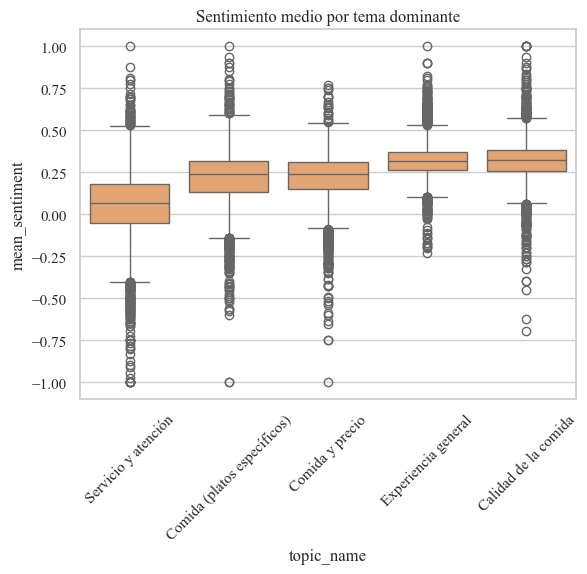

In [47]:
#TEMA VS SENTIMIENTO
sns.boxplot(
    data=X_train_nlpr,
    x="topic_name",
    y="mean_sentiment",
    color="#F4A261"
)

plt.title("Sentimiento medio por tema dominante")
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='cluster'>

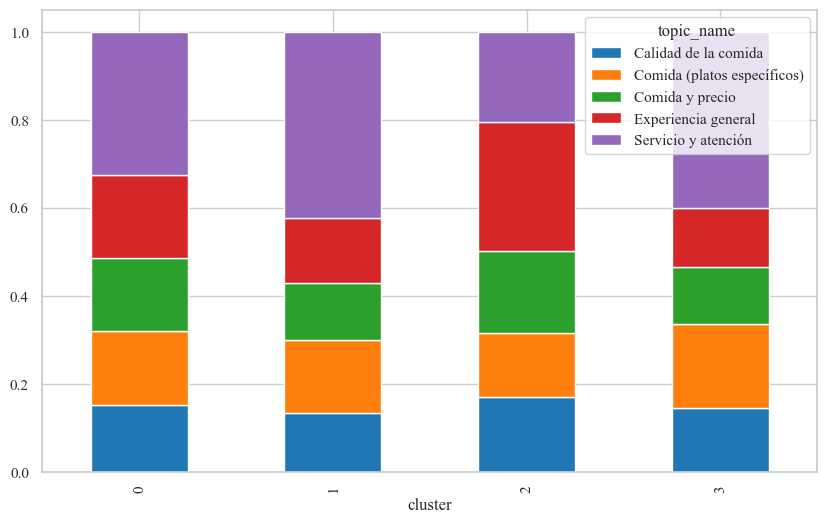

In [48]:
#TEMA VS CLUSTER
pd.crosstab(
    X_train_nlpr["cluster"],
    X_train_nlpr["topic_name"],
    normalize="index"
).plot(kind="bar", stacked=True, figsize=(10,6))

In [49]:
y_clf = y_clf["is_open"]

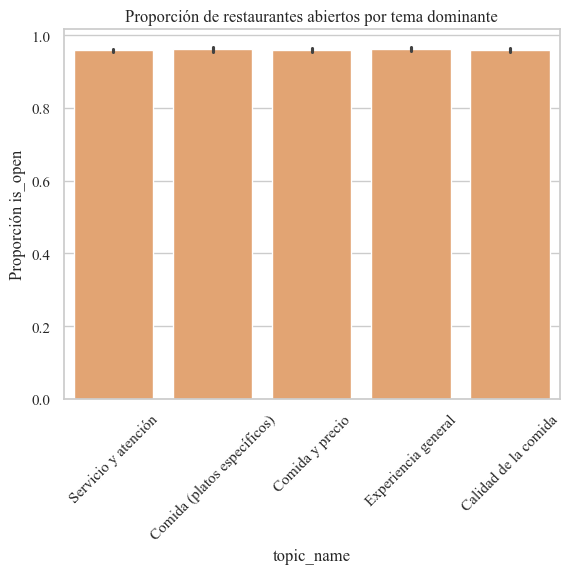

In [50]:
sns.barplot(
    x=X_train_nlpr["topic_name"].reset_index(drop=True),
    y=y_clf.reset_index(drop=True)[:len(X_train_nlpr)],
    color="#F4A261"
)

plt.title("Proporción de restaurantes abiertos por tema dominante")
plt.ylabel("Proporción is_open")
plt.xticks(rotation=45)
plt.show()

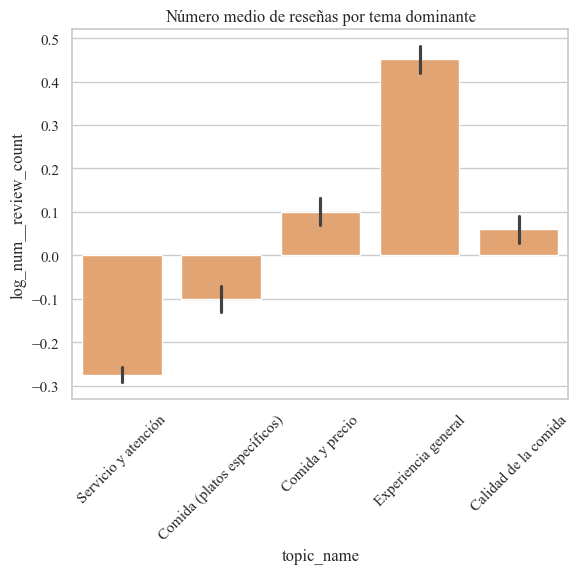

In [51]:
#TEMA VS NÚMERO DE RESEÑAS
sns.barplot(
    data=X_train_nlpr,
    x="topic_name",
    y="log_num__review_count",
    color="#F4A261"
)

plt.title("Número medio de reseñas por tema dominante")
plt.xticks(rotation=45)
plt.show()

In [52]:
X_train_nlpr.groupby("topic_name")["log_num__review_count"].mean()

topic_name
Calidad de la comida           0.060930
Comida (platos específicos)   -0.101588
Comida y precio                0.100496
Experiencia general            0.450988
Servicio y atención           -0.275042
Name: log_num__review_count, dtype: float64

In [53]:
X_train_nlpr.groupby("topic_name")["log_num__n_checkins"].mean()

topic_name
Calidad de la comida           0.027701
Comida (platos específicos)   -0.220029
Comida y precio               -0.037349
Experiencia general            0.352735
Servicio y atención           -0.084542
Name: log_num__n_checkins, dtype: float64

In [54]:
X_train_nlpr.groupby("topic_name")["avg_review_stars"].mean()

topic_name
Calidad de la comida           4.343550
Comida (platos específicos)    3.610507
Comida y precio                3.779275
Experiencia general            4.191487
Servicio y atención            2.390249
Name: avg_review_stars, dtype: float64

<Axes: xlabel='topic_name', ylabel='avg_review_stars'>

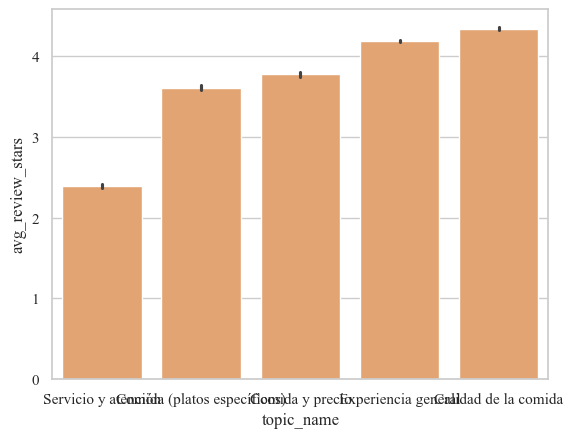

In [55]:
sns.barplot(
    data=X_train_nlpr,
    x="topic_name",
    y="avg_review_stars",
    color="#F4A261"
)

In [56]:
#Convertir a CSV
X_train_mod.to_csv("X_train_mod.csv", index=False)
X_test_mod.to_csv("X_test_mod.csv", index=False)

In [57]:

X_train_mod = pd.read_csv("X_train_mod.csv", encoding="latin1")
X_train_mod.dtypes

log_num__review_count    float64
log_num__n_reviews       float64
log_num__sum_useful      float64
log_num__n_checkins      float64
num__latitude            float64
                          ...   
mean_sentiment           float64
std_sentiment            float64
positive_ratio           float64
negative_ratio           float64
topic_name                object
Length: 73, dtype: object